In [3]:
import pandas as pd

df = pd.read_csv("twitter_training.csv", header = None, names = ['tweet_id','entity','sentiment','text'])
df.head(10)

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.isnull().sum()

,0
tweet_id,0
entity,0
sentiment,0
text,686


In [6]:
df = df.dropna(subset = ['text'])
df.shape

(73996, 4)

In [7]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


In [8]:
import re

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # URLs hatao
    text = re.sub(r'@\w+', '', text)                   # mentions hatao
    text = re.sub(r'#\w+', '', text)                   # hashtags hatao
    text = re.sub(r'[^a-z\s]', '', text)                # numbers/special chars hatao
    text = re.sub(r'\s+', ' ', text).strip()            # extra spaces hatao
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


/tmp/ipykernel_5683/2065837347.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')


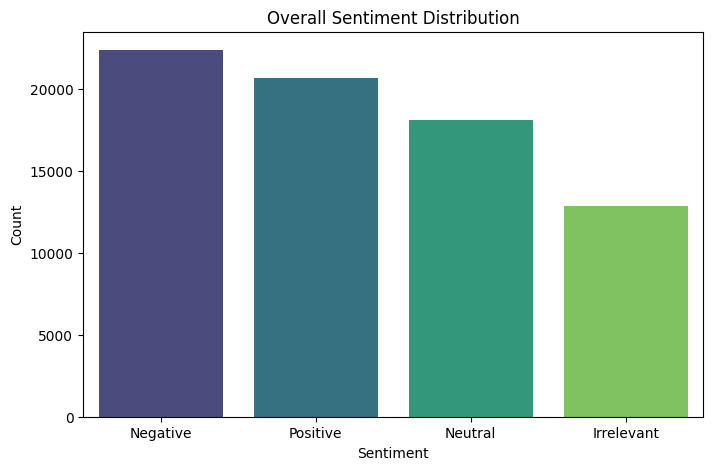

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

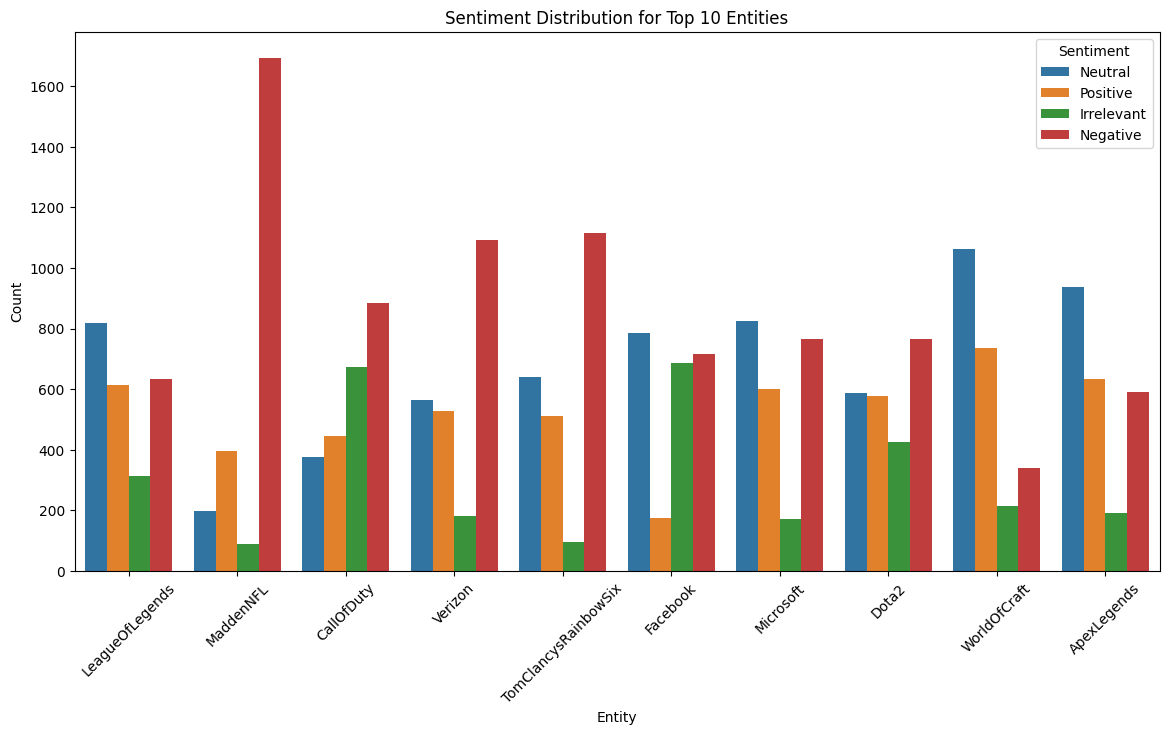

In [10]:
top_entities = df['entity'].value_counts().head(10).index
df_top = df[df['entity'].isin(top_entities)]

plt.figure(figsize=(14,7))
sns.countplot(data=df_top, x='entity', hue='sentiment', order=top_entities)
plt.title('Sentiment Distribution for Top 10 Entities')
plt.xlabel('Entity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

In [11]:
!pip install wordcloud -q
from wordcloud import WordCloud

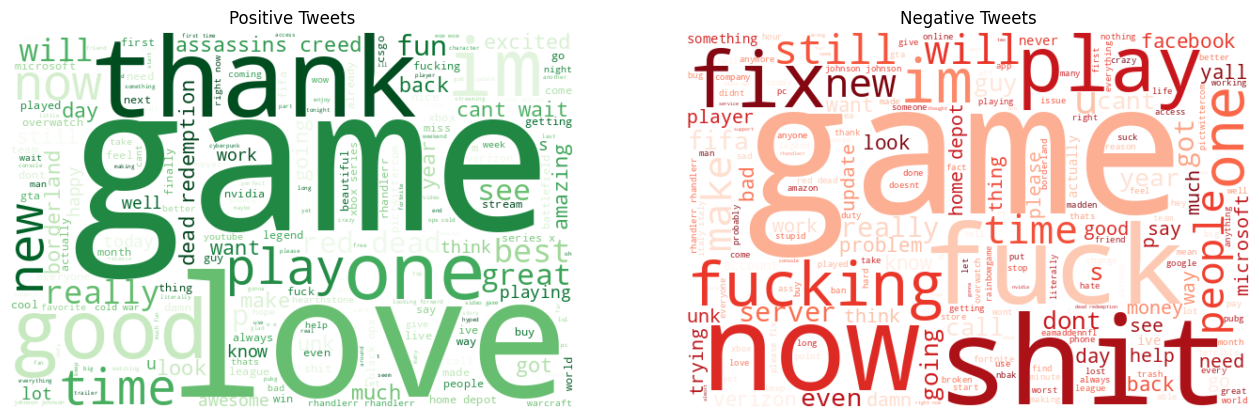

In [12]:
positive_text = ' '.join(df[df['sentiment']=='Positive']['clean_text'])
negative_text = ' '.join(df[df['sentiment']=='Negative']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16,8))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Tweets')
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Tweets')
axes[1].axis('off')

plt.show()

In [13]:
entity_sentiment = pd.crosstab(df_top['entity'], df_top['sentiment'], normalize='index') * 100
entity_sentiment = entity_sentiment.round(1)
print(entity_sentiment)


sentiment             Irrelevant  Negative  Neutral  Positive
entity                                                       
ApexLegends                  8.2      25.1     39.8      26.9
CallOfDuty                  28.3      37.2     15.8      18.8
Dota2                       18.0      32.5     24.9      24.5
Facebook                    29.0      30.3     33.3       7.4
LeagueOfLegends             13.1      26.6     34.4      25.9
MaddenNFL                    3.8      71.3      8.3      16.7
Microsoft                    7.2      32.4     34.9      25.5
TomClancysRainbowSix         4.1      47.2     27.1      21.7
Verizon                      7.6      46.2     23.9      22.3
WorldOfCraft                 9.2      14.4     45.1      31.3
